In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

In [3]:
df_Amoxycillin = pd.read_csv("dataset_amoxy.csv", low_memory=False)

In [4]:
df_Amoxycillin.reset_index(inplace= True)
df_Amoxycillin.columns

Index(['index', 'Unnamed: 0', 'Species', 'Organism Group', 'Country', 'Year',
       'Source', 'Value', 'Value_I'],
      dtype='str')

In [5]:
df = df_Amoxycillin[df_Amoxycillin.Value.notna()]
df = df.reset_index()

In [6]:
df = df[df.columns.drop(['level_0', 'index', 'Unnamed: 0'])]

In [7]:
df = df[df.Value_I.notna()]

In [8]:
df.index = [i for i in range(323656)]

In [9]:
df_small = df.sample(30000, random_state=42)

In [10]:
df_small['Year_c'] = df_small['Year'] - df_small['Year'].mean()
species_idx, species = pd.factorize(df_small["Species"])
country_idx, country = pd.factorize(df_small["Country"])
source_idx, source = pd.factorize(df_small["Source"])

df_small["species_idx"] = species_idx
df_small["country_idx"] = country_idx
df_small["source_idx"] = source_idx

In [11]:
l = []
for i in df_small.Value_I:
    if(i == 'Resistant'):
        l.append(1)
    else:
        l.append(0)

df_small['resistant'] = l
del(l)

In [12]:
n_species = len(species)
n_country = len(country)
n_source = len(source)

In [13]:
df_small

,Species,Organism Group,Country,Year,Source,Value,Value_I,Year_c,species_idx,country_idx,source_idx,resistant
121137,Klebsiella pneumoniae,Enterobacteriaceae,United States,2004,ENT,4.00,Susceptible,-7.6883,0,0,0,0
237461,Serratia marcescens,Enterobacteriaceae,Mexico,2009,BF,32.00,Resistant,-2.6883,1,1,1,1
7123,Providencia rettgeri,Enterobacteriaceae,Sweden,2013,GI,16.00,Resistant,1.3117,2,2,2,1
189416,Klebsiella aerogenes,Enterobacteriaceae,India,2007,RSP,16.00,Intermediate,-4.6883,3,3,3,0
213619,Klebsiella pneumoniae,Enterobacteriaceae,Italy,2008,GU,32.00,Resistant,-3.6883,0,4,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...
84497,Escherichia coli,Enterobacteriaceae,Mexico,2016,INT,4.00,Susceptible,4.3117,5,1,6,0
295408,Klebsiella pneumoniae,Enterobacteriaceae,Turkey,2012,GU,16.00,Resistant,0.3117,0,42,4,1
183408,Serratia marcescens,Enterobacteriaceae,United States,2007,CVS,32.00,Resistant,-4.6883,1,0,5,1
155349,Streptococcus pneumoniae,Streptococcus pneumoniae,Japan,2017,RSP,0.06,Susceptible,5.3117,9,51,3,0


In [14]:
import pymc as pm

with pm.Model() as model:

    # priors
    intercept = pm.Normal("intercept", 0, 5)
    beta_year = pm.Normal("beta_year", 0, 1)
    
    beta_source = pm.Normal("beta_source", 0, 1, shape=n_source)

    # hierarchical std
    sigma_species = pm.HalfNormal("sigma_species", 1)
    sigma_country = pm.HalfNormal("sigma_country", 1)

    # hierarchical effects
    species_effect = pm.Normal("species_effect", 0, sigma_species, shape=n_species)
    country_effect = pm.Normal("country_effect", 0, sigma_country, shape=n_country)

    logit_p = (
        intercept
        + beta_year * df_small["Year_c"].values
        + beta_source[df_small["source_idx"].values]
        + species_effect[df_small["species_idx"].values]
        + country_effect[df_small["country_idx"].values]
    )

    # likelihood
    y = pm.Bernoulli(
        "y",
        logit_p=logit_p,
        observed=df_small["resistant"].values)

In [17]:
trace = az.from_netcdf("trace_amoxy.nc")

In [18]:
with model:
    ppc = pm.sample_posterior_predictive(trace, var_names=["y"])

Sampling: [y]


/home/dark/Desktop/Project2/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" 
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [19]:
ppc

Inference data with groups:
	> posterior_predictive
	> observed_data

<Axes: xlabel='y'>

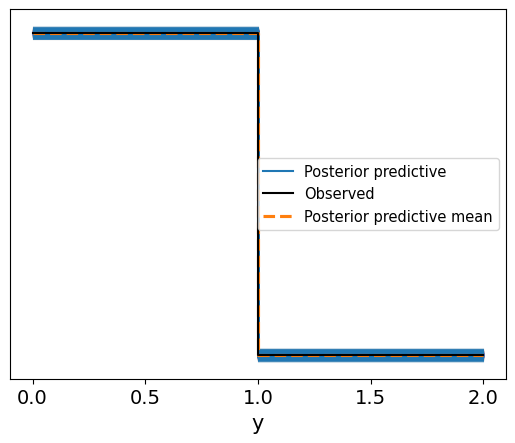

In [20]:
az.plot_ppc(ppc, kind = 'kde')